In [1]:
%run general_functions.ipynb

In [2]:
def depth_integral(ds, var):
    
    # ds = ds.fillna(0)
    layers_sum = [
        ds[var].isel(deptht=x) * (ds.deptht[x] if x == 0 else (ds.deptht[x] - ds.deptht[x - 1]))
        for x in range(len(ds.deptht))
    ]
                            # kg m-3   mol
    total = (sum(layers_sum) * 1025 * 1e-6).to_dataset(name=var) # kg mol-1
    
    return total

In [18]:
def integral(ds, var):
    
    earth_radius = 6.371e6 # in m

    weights = np.cos(np.deg2rad(ds.nav_lat))
    ds_fin = ds.weighted(weights)
    ds_fin = ds_fin.mean(("x", "y"))

                            #  s-1 > y-1          # earth's surface       
    ds_fin[var] = ds_fin[var] * 31536000 * (4 * math.pi * (earth_radius**2)) 
    
                            # umol > Tmol  for alkalinity
    ds_fin[var] = ds_fin[var] * 1e-18
    
    return ds_fin

In [4]:
def es_efficiency(carbon, c_var, alkalinity, a_var):

    efficiency = carbon[c_var] / alkalinity[a_var]
    
    print(efficiency.plot())

In [5]:
path = '/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/last_decade/'

# CO2 datasets

co2flux_base = xr.open_dataset(path+'co2flux_base26.nc')
co2flux_oae = xr.open_dataset(path+'co2flux_oae26.nc')

# DIC datasets

dic_base = xr.open_dataset(path+'dic_base70.nc')
dic_oae = xr.open_dataset(path+'/dic_oae70.nc')

In [20]:
# years = list(range(2014,2105,1))
# for i in years:
#     year = xr.open_dataset(f"/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/alkalinity_mask_y{i}.nc")
#     print(i, integral(year,'alk_flux'))

In [7]:
input_dir = '/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/'

files = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.nc')])

datasets = []

for i, f in enumerate(files):
    ds = xr.open_dataset(f)
    
    ds = ds.expand_dims(dim={'time_counter': [i]})
    
    datasets.append(ds)

combined = xr.concat(datasets, dim='time_counter')

combined['time_counter'] = np.arange(1, len(files)+1) 
combined = combined.sel(x=slice(520, 595), y=slice(330, 435))
combined = combined.where(combined)

In [8]:
# add datetime dimension and slice 

n_years = combined.dims['time_counter']
new_time = pd.date_range(start='2014-01-01', periods=n_years, freq='YS')  # 'YS' = Year Start

combined['time_counter'] = new_time
combined = combined.sel(time_counter=slice('2090','2099'))

In [9]:
# ocean mask

mesk_mask = xr.open_dataset(path+'/mesh_mask.nc')
dx, dy = mesk_mask.e1t, mesk_mask.e2t
grid_cell_area = (dx * dy).isel(t=0)

mesk_mask['tmask'] = mesk_mask['tmask'].where(mesk_mask['tmask']!=0)
grid_cell_ocean = (mesk_mask['tmask'].isel(t=0,z=0)*grid_cell_area)
grid_cell_ocean = grid_cell_ocean.where(grid_cell_ocean)

ocean_slice = grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435)) 

In [10]:
# coastline mask

alk_mask_nans = xr.where(combined.notnull(), 1, np.nan)
alk_mask_nans = alk_mask_nans.where(alk_mask_nans)
coastline_ocean = (ocean_slice * alk_mask_nans).isel(time_counter=0)

In [11]:
# total alkalinity change
                                 # umol>mol   s-1>y-1     slice                   # m-2>-
alk_change = ((combined['alk_flux'] * 1e-6 * 31536000 * coastline_ocean * 10).sum(dim=['x','y'])).groupby("time_counter.year").mean("time_counter") # mol

In [12]:
# dic change integral

dic_change = (dic_oae['DIC'] - dic_base['DIC']).to_dataset(name='DIC')
dic_change = ((depth_integral(dic_change, 'DIC')) * ocean_slice).sum(['x','y']) # mol 
dic_integral = (dic_change.groupby("time_counter.year").mean("time_counter"))

In [13]:
# co2 flux change integral

co2flux_change = co2flux_oae - co2flux_base
                                                       # kg>g    g>mol     s>y                   m2>-
co2flux_change['co2flux'] = (co2flux_change['co2flux'] * 1000 / 44.009 * 31536000 * ocean_slice).sum(dim=['x','y']) # mol y-1
co2flux_change = co2flux_change.groupby("time_counter.year").mean("time_counter")

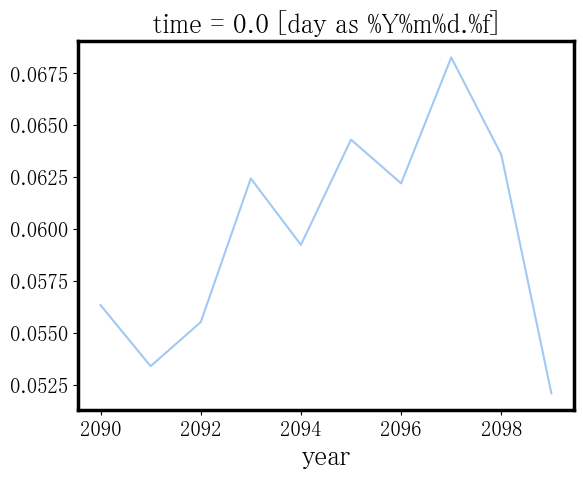

In [47]:
es_efficiency(-co2flux_change, 'co2flux', alk_change, 'alk_flux')